# 3. You cannot have every fairness definition at once

**Claim under test:** the output of a data pipeline can be "cleaned, balanced,
compliant", as if fairness were a property you finish installing.

When base rates differ between groups, fairness criteria conflict, and the
conflict appears at the threshold rather than in the data.

Be precise about what is and is not a theorem. **Kleinberg et al. (2016) and
Chouldechova (2017) are about calibration versus error-rate balance** - you
cannot have calibration, equal false positive rates and equal false negative
rates together unless base rates are equal or prediction is perfect. Neither
theorem is about demographic parity.

Demographic parity conflicts with calibration too, but for a simpler reason: if
the groups differ in base rate, a calibrated score will select them at different
rates by construction. That is arithmetic, not the impossibility result. This
notebook shows the demographic-parity tension; the COMPAS notebook shows the
actual theorem.

- Kleinberg, Mullainathan & Raghavan (`papers/kleinberg-2016-inherent-tradeoffs.pdf`)
- Chouldechova (`papers/chouldechova-2017-fair-prediction.pdf`)
- Narayanan, *21 Fairness Definitions and Their Politics* - why the choice is political
- Hardt, Price & Srebro (2016) - equalised odds


In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

RNG = np.random.default_rng(3)
N = 20000

group_b = RNG.random(N) < 0.35
x = RNG.normal(np.where(group_b, -0.45, 0.15), 1.0, N)     # risk signal
y = RNG.binomial(1, 1 / (1 + np.exp(-(1.4 * x + 0.4))))    # true outcome

X = pd.DataFrame({'x': x})
p = LogisticRegression().fit(X, y).predict_proba(X)[:, 1]

a, b = ~group_b, group_b
print(f'base rate   A={y[a].mean():.1%}   B={y[b].mean():.1%}   <- genuinely different')

base rate   A=60.7%   B=46.9%   <- genuinely different


The base rates differ. That single fact is what makes the rest impossible. Note
the model never sees group membership.

In [2]:
def report(decision, title):
    print(title)
    stats = {}
    for name, mask in (('A', a), ('B', b)):
        yy, dd = y[mask], decision[mask]
        stats[name] = dict(sel=dd.mean(), tpr=dd[yy == 1].mean(),
                           fpr=dd[yy == 0].mean(), ppv=yy[dd].mean())
        s = stats[name]
        print(f"   {name}: selected={s['sel']:.1%}  TPR={s['tpr']:.3f}  "
              f"FPR={s['fpr']:.3f}  PPV={s['ppv']:.3f}")
    print(f"   demographic parity ratio = {stats['B']['sel'] / stats['A']['sel']:.2f}")
    print(f"   TPR gap = {abs(stats['A']['tpr'] - stats['B']['tpr']):.3f}   "
          f"PPV gap = {abs(stats['A']['ppv'] - stats['B']['ppv']):.3f}\n")


report(p >= 0.5, 'ONE THRESHOLD FOR EVERYONE (group-blind, calibrated)')

t_a = np.quantile(p[a], 1 - 0.35)
t_b = np.quantile(p[b], 1 - 0.35)
report(np.where(b, p >= t_b, p >= t_a), 'FORCED DEMOGRAPHIC PARITY (35% accepted in each group)')
print(f'   thresholds: A={t_a:.3f}  B={t_b:.3f}  '
      f'-> the same score is treated differently depending on group')

ONE THRESHOLD FOR EVERYONE (group-blind, calibrated)
   A: selected=66.8%  TPR=0.837  FPR=0.407  PPV=0.761
   B: selected=45.1%  TPR=0.697  FPR=0.234  PPV=0.725
   demographic parity ratio = 0.68
   TPR gap = 0.140   PPV gap = 0.036

FORCED DEMOGRAPHIC PARITY (35% accepted in each group)
   A: selected=35.0%  TPR=0.504  FPR=0.111  PPV=0.875
   B: selected=35.0%  TPR=0.579  FPR=0.148  PPV=0.776
   demographic parity ratio = 1.00
   TPR gap = 0.074   PPV gap = 0.099

   thresholds: A=0.764  B=0.589  -> the same score is treated differently depending on group


## Is the model calibrated?

Calibration means a predicted 0.7 corresponds to a real 70%, within each group.
It is the property a lender most wants, and the group-blind model has it.

In [3]:
for name, mask in (('A', a), ('B', b)):
    frac, mean_pred = calibration_curve(y[mask], p[mask], n_bins=5, strategy='quantile')
    print(f'  {name}: predicted {np.round(mean_pred, 3)}')
    print(f'     actual    {np.round(frac, 3)}')

  A: predicted [0.22  0.465 0.648 0.797 0.923]
     actual    [0.216 0.452 0.649 0.794 0.925]
  B: predicted [0.109 0.277 0.455 0.636 0.838]
     actual    [0.115 0.276 0.444 0.663 0.849]


## Read the numbers

The group-blind model is well calibrated in both groups: predicted and actual
line up. It also fails the four-fifths rule at 0.68.

Forcing parity fixes that ratio and changes three other things. The PPV gap
opens, so "accepted" means something different depending on group. The two
thresholds differ, so the same score produces a different decision by group -
which in lending is a legal problem, not a technical one. And the TPR gap
actually *narrows*, from about 0.14 to about 0.07, which is worth stating
because it cuts in favour of the intervention rather than against it.

So this is a trade, not a catastrophe: parity and equal opportunity improve,
calibration-conditional-on-score and equal treatment of equal scores get worse.
Which of those you want is a judgement. What you cannot do is have all of them,
and that follows from the base rates differing.


## The picture


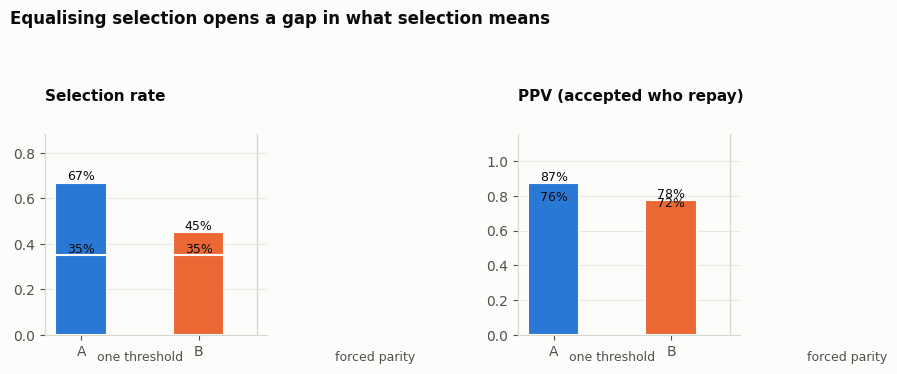

In [4]:
import matplotlib.pyplot as plt

BLUE, ORANGE, AQUA = '#2a78d6', '#eb6834', '#1baf7a'
INK, MUTED, SURFACE = '#0b0b0b', '#52514e', '#fcfcfb'
plt.rcParams.update({'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE,
                     'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'bold',
                     'axes.labelcolor': MUTED, 'text.color': INK,
                     'xtick.color': MUTED, 'ytick.color': MUTED})


def tidy(ax, xgrid=True):
    for s in ('top', 'right'):
        ax.spines[s].set_visible(False)
    for s in ('left', 'bottom'):
        ax.spines[s].set_color('#d8d7d2')
    ax.grid(axis='x' if xgrid else 'y', color='#e8e7e2', lw=0.8)
    ax.set_axisbelow(True)

def collect(decision):
    out = []
    for mask in (a, b):
        yy, dd = y[mask], decision[mask]
        out.append((dd.mean(), yy[dd].mean()))
    return out

blind = collect(p >= 0.5)
forced = collect(np.where(b, p >= t_b, p >= t_a))

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.9))
for ax, idx, title in ((axes[0], 0, 'Selection rate'), (axes[1], 1, 'PPV (accepted who repay)')):
    vals = [blind[0][idx], blind[1][idx], forced[0][idx], forced[1][idx]]
    bars = ax.bar(['A', 'B', 'A', 'B'], vals,
                  color=[BLUE, ORANGE, BLUE, ORANGE], width=0.44, zorder=3, edgecolor=SURFACE, lw=1.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.012, f'{v:.0%}',
                ha='center', fontsize=9, color=INK)
    ax.axvline(1.5, color='#d8d7d2', lw=1)
    ax.text(0.5, -0.13, 'one threshold', ha='center', color=MUTED, fontsize=9,
            transform=ax.get_xaxis_transform())
    ax.text(2.5, -0.13, 'forced parity', ha='center', color=MUTED, fontsize=9,
            transform=ax.get_xaxis_transform())
    tidy(ax, xgrid=False)
    ax.set_title(title, loc='left', pad=24)
    ax.set_ylim(0, max(vals) * 1.32)
fig.suptitle('Equalising selection opens a gap in what selection means',
             x=0.012, ha='left', fontsize=12, fontweight='bold')
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.savefig('../figures/03_impossibility.png', dpi=150, bbox_inches='tight')
plt.show()